In [1]:
#import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_brute=pd.read_csv("..\CIC-IDS2017-Dataset\Bruteforce-Tuesday-no-metadata.parquet.csv")

In [3]:
print("Cleaning headers and dropping mathematical anomalies...")

# Strip accidental whitespaces from column names
df_brute.columns = df_brute.columns.str.strip()

# Replace any infinities with NaN and drop them cleanly
df_brute.replace([np.inf, -np.inf], np.nan, inplace=True)
df_brute.dropna(inplace=True)

print("Data infrastructure validated and clean.")

Cleaning headers and dropping mathematical anomalies...


Data infrastructure validated and clean.


Analyzing target class distributions...
Label
Benign         380564
FTP-Patator      5931
SSH-Patator      3219
Name: count, dtype: int64


C:\Users\admin\AppData\Local\Temp\ipykernel_25188\3575108745.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


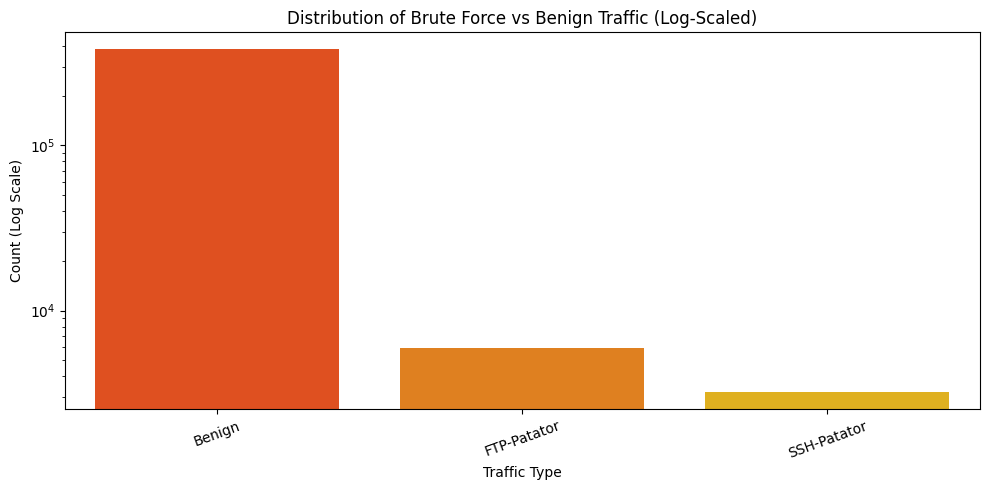

In [4]:
print("Analyzing target class distributions...")

# Print numerical breakdown of brute force categories vs benign background traffic
print(df_brute['Label'].value_counts())

# Generate Log-Scaled Count Plot
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=df_brute, 
    x='Label', 
    order=df_brute['Label'].value_counts().index, 
    palette='autumn'
)
ax.set_yscale('log')  # Force log scale so minority attack classes show up visually
plt.xticks(rotation=20)
plt.title('Distribution of Brute Force vs Benign Traffic (Log-Scaled)')
plt.ylabel('Count (Log Scale)')
plt.xlabel('Traffic Type')
plt.tight_layout()
plt.show()

Plotting backward packet size structure...


C:\Users\admin\AppData\Local\Temp\ipykernel_25188\2779192660.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_brute, x='Label', y='Bwd Packet Length Max', palette='Set2')


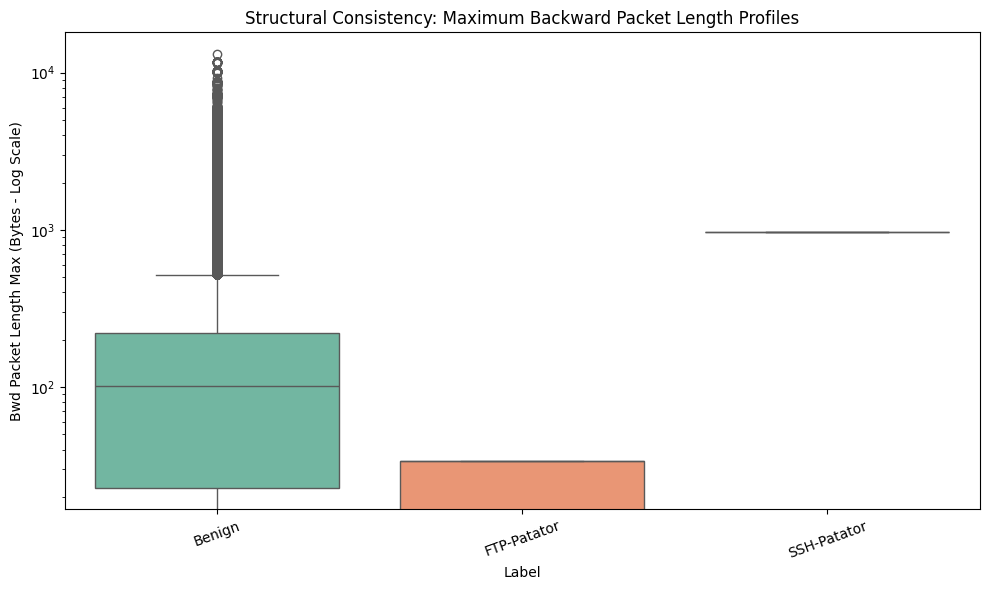

In [5]:
print("Plotting backward packet size structure...")

plt.figure(figsize=(10, 6))
# Bwd Packet Length Max exposes the uniform size of repetitive server error messages
sns.boxplot(data=df_brute, x='Label', y='Bwd Packet Length Max', palette='Set2')
plt.yscale('log')
plt.xticks(rotation=20)
plt.title('Structural Consistency: Maximum Backward Packet Length Profiles')
plt.ylabel('Bwd Packet Length Max (Bytes - Log Scale)')
plt.tight_layout()
plt.show()

Checking the target port clusters...


C:\Users\admin\AppData\Local\Temp\ipykernel_25188\3866376322.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=attack_df, x='Protocol', palette='crest')


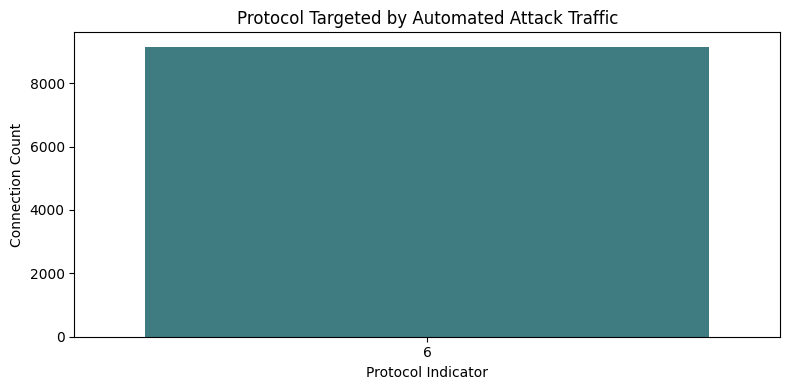

Attack distribution by Protocol:
Protocol
6    9150
Name: count, dtype: int64


In [6]:
print("Checking the target port clusters...")

# Target the port column if it exists in your dataset schema
port_column = 'Destination Port' 

# Filter for attack traffic only to isolate the attacker's true intent
attack_df = df_brute[df_brute['Label'] != 'Benign']

if port_column in df_brute.columns:
    plt.figure(figsize=(10, 5))
    # Plotting the top targeted ports to catch the sharp authentication gateway spikes
    ax = sns.countplot(
        data=attack_df, 
        x=port_column, 
        order=attack_df[port_column].value_counts().iloc[:5].index,
        palette='crest'
    )
    plt.title('Target Port Clustering (Attack Traffic Only)')
    plt.xlabel('Destination Port (e.g., 21 for FTP, 22 for SSH)')
    plt.ylabel('Connection Count')
    plt.tight_layout()
    plt.show()
    
    print("Top targeted ports by attack scripts:")
    print(attack_df[port_column].value_counts().head(5))
else:
    print(f"Warning: '{port_column}' not found in this dataset. Visualizing 'Protocol' distribution instead:")
    plt.figure(figsize=(8, 4))
    sns.countplot(data=attack_df, x='Protocol', palette='crest')
    plt.title('Protocol Targeted by Automated Attack Traffic')
    plt.xlabel('Protocol Indicator')
    plt.ylabel('Connection Count')
    plt.tight_layout()
    plt.show()
    
    print("Attack distribution by Protocol:")
    print(attack_df['Protocol'].value_counts())

Plotting attack script timing patterns...


C:\Users\admin\AppData\Local\Temp\ipykernel_25188\249412531.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_brute, x='Label', y='Fwd IAT Mean', palette='rocket')


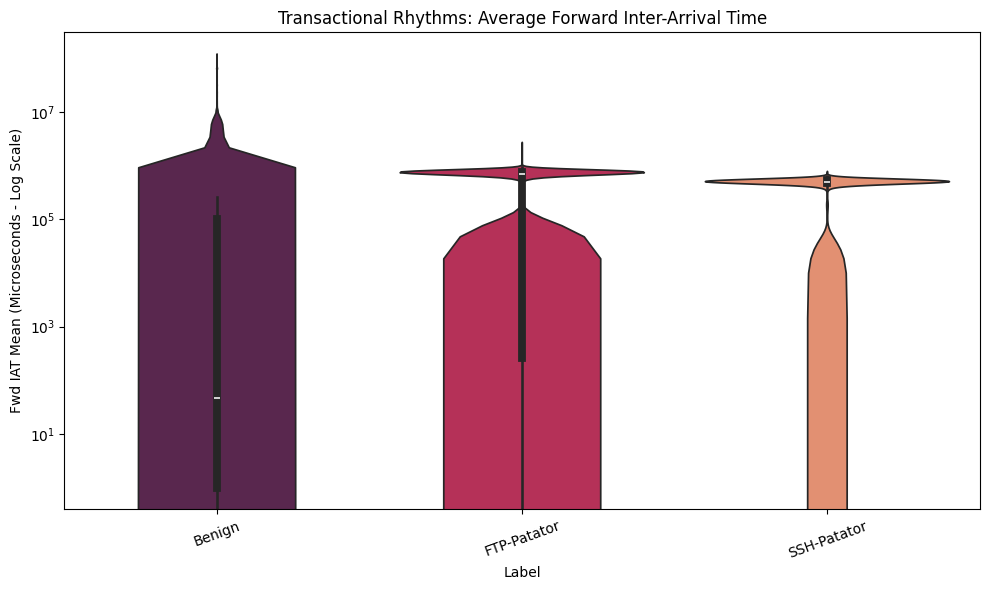

In [7]:
print("Plotting attack script timing patterns...")

plt.figure(figsize=(10, 6))
# Mean Forward Inter-Arrival Time catches the steady, rapid pacing of automated scripts
sns.violinplot(data=df_brute, x='Label', y='Fwd IAT Mean', palette='rocket')
plt.yscale('log')
plt.xticks(rotation=20)
plt.title('Transactional Rhythms: Average Forward Inter-Arrival Time')
plt.ylabel('Fwd IAT Mean (Microseconds - Log Scale)')
plt.tight_layout()
plt.show()

In [8]:
print("Executing brute-force specific feature engineering...")

# 1. Interaction Density (Using 'Total Fwd Packets' and 'Total Backward Packets')
df_brute['Interaction_Density'] = (df_brute['Total Fwd Packets'] + df_brute['Total Backward Packets']) / (df_brute['Flow Duration'] + 1)

# 2. Size Symmetry Coefficient (Exposes small request/response lockstep pairs)
df_brute['Size_Symmetry'] = (df_brute['Fwd Packet Length Max'] + 1) / (df_brute['Bwd Packet Length Max'] + 1)

# 3. Log transformations with a lower bound clip to cleanly squash wild outlier skews
df_brute['Log_Flow_Duration'] = np.log1p(df_brute['Flow Duration'].clip(lower=0))
df_brute['Log_Fwd_IAT_Mean'] = np.log1p(df_brute['Fwd IAT Mean'].clip(lower=0))

print("Engineered behavioral indicators attached successfully with zero warnings!")

Executing brute-force specific feature engineering...
Engineered behavioral indicators attached successfully with zero warnings!


Generating correlation matrix to prune irrelevant volumetric columns...


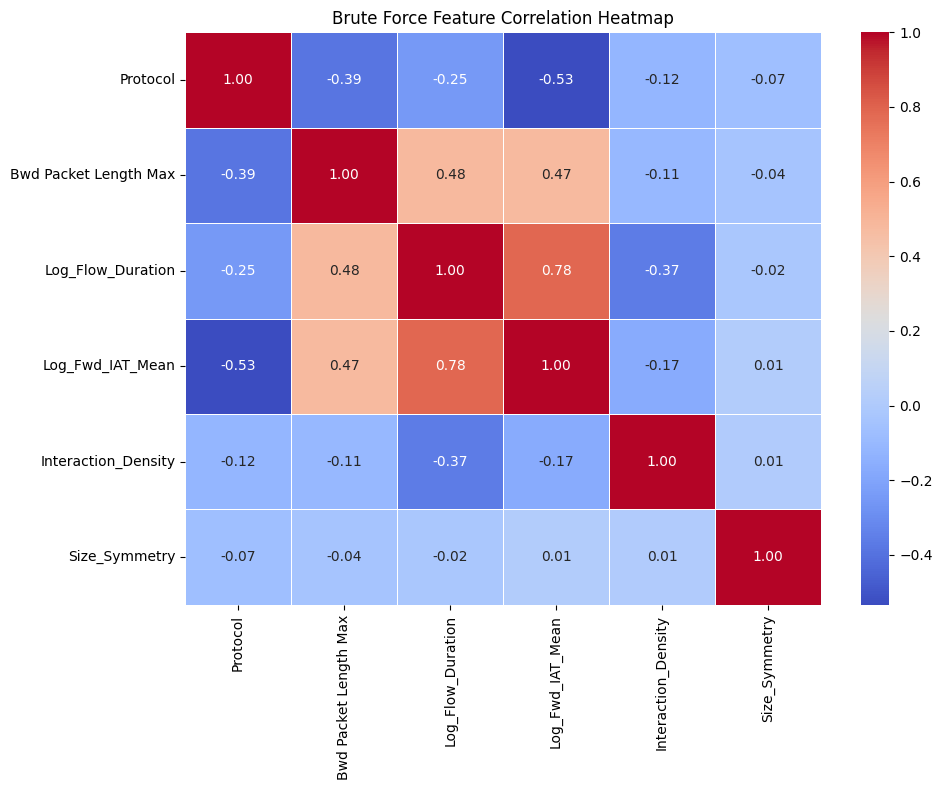


Dead features with zero informational variance: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Pipeline complete! The processed brute force data is optimized for ML modeling.


In [9]:
print("Generating correlation matrix to prune irrelevant volumetric columns...")

# Removed the port column entirely and added 'Protocol' which exists in your list
brute_features = [
    'Protocol', 'Bwd Packet Length Max', 'Log_Flow_Duration', 
    'Log_Fwd_IAT_Mean', 'Interaction_Density', 'Size_Symmetry'
]

plt.figure(figsize=(10, 8))
corr_matrix = df_brute[brute_features].corr()

# Render the correlation grid
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Brute Force Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Detect and print dead columns with zero variance
zero_variance = [col for col in df_brute.columns if df_brute[col].nunique() == 1]
print(f"\nDead features with zero informational variance: {zero_variance}")
print("\nPipeline complete! The processed brute force data is optimized for ML modeling.")

In [10]:
print([col for col in df_brute.columns if 'Port' in col or 'port' in col])

[]


In [11]:
print(list(df_brute.columns))

['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ra

 Visualizing the composition of malicious traffic...


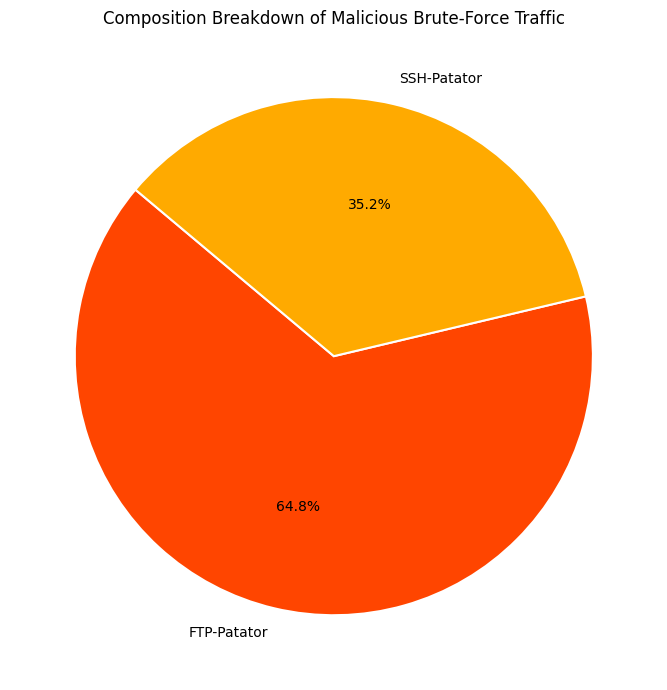

Malicious traffic breakdown counts:
Label
FTP-Patator    5931
SSH-Patator    3219
Name: count, dtype: int64


In [12]:
print(" Visualizing the composition of malicious traffic...")

# Filter the dataset to isolate ONLY attack classes
attack_df = df_brute[df_brute['Label'] != 'Benign']

# Generate the pie chart for attack composition
plt.figure(figsize=(7, 7))
attack_counts = attack_df['Label'].value_counts()

plt.pie(
    attack_counts, 
    labels=attack_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#ff4500', '#ffaa00'],  # Distinctive malicious threat colors
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Composition Breakdown of Malicious Brute-Force Traffic')
plt.tight_layout()
plt.show()

print("Malicious traffic breakdown counts:")
print(attack_counts)